<a href="https://colab.research.google.com/github/rioAgustian/pytorch_deep_learning/blob/main/02_pytorch_neural_network_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. Neural Network classification with PyTorch

## 1. Make classification data and get it ready

In [1]:
from sklearn.datasets import make_circles

# Make samples
n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)
len(X), len(y)

(1000, 1000)

In [2]:
print(f"First 5 samples of X:\n {X[:5]}")
print(f"First 5 samples of y:\n {y[:5]}")

First 5 samples of X:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y:
 [1 1 1 1 0]


In [3]:
# DataFrame
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                        "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


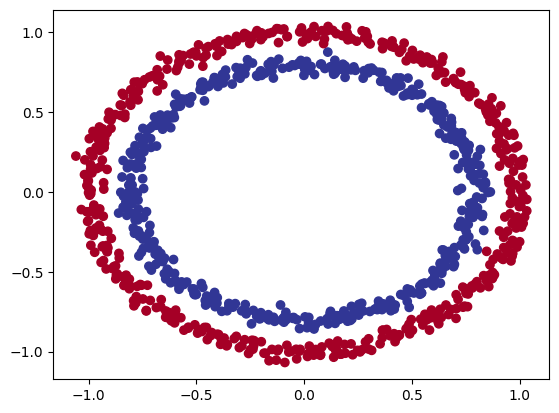

In [4]:
import matplotlib.pyplot as plt

plt.scatter(x=X[:, 0], y=X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.show()

In [5]:
X.shape, y.shape

((1000, 2), (1000,))

In [6]:
# See some data
X_sample = X[0]
y_sample = y[0]

print(f"Value for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same fpr y: {y_sample.shape}")

Value for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same fpr y: ()


### 1.2 Turn data to tensors and create train-test split

In [7]:
import numpy as np
import torch

# Turn data to tensor
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [8]:
# train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2. Build a model

In [9]:
import torch
from torch import nn

# Device agnostic
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [10]:
# First method
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=5) # shape X_train itu 800, 2,
    self.layer_2 = nn.Linear(in_features=5, out_features=1) # shape y_train 800, 1

  def forward(self, x):
    return self.layer_2(self.layer_1(x))

model_0 = CircleModelV0().to(device)

In [11]:
# Second method
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.ReLU(),
    nn.Linear(in_features=5, out_features=1)
).to(device)

In [12]:
# Loss function & optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

# Accuracy
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc     = (correct / len(y_pred)) * 100
  return acc

## 3. Train model

In [13]:
# Output of the model
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))

y_pred_probs = torch.sigmoid(y_logits) # prediction from 0-1
# torch.round(y_pred_probs) # rounding

In [14]:
torch.manual_seed(42)

epochs = 10000
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  # Forwardprop
  model_0.train()
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # calculate the loss/accuracy
  loss = loss_fn(y_logits, y_train) # Expect logits as input
  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

  # optimizer zero grad
  optimizer.zero_grad()

  # Backprop
  loss.backward()

  # Gradient descent
  optimizer.step()

  # Testing
  model_0.eval()
  with torch.inference_mode():
    # Forwardprop
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # Test loss/accuracy
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

  if epoch % 200 ==0:
    print(f"Epoch: {epoch} | Loss: {loss:5f} | Test loss: {test_loss:.5f} | Accuracy: {acc} | Test accuracy: {test_acc}")

Epoch: 0 | Loss: 0.690412 | Test loss: 0.68599 | Accuracy: 50.0 | Test accuracy: 56.00000000000001
Epoch: 200 | Loss: 0.685018 | Test loss: 0.67905 | Accuracy: 51.625 | Test accuracy: 56.00000000000001
Epoch: 400 | Loss: 0.681699 | Test loss: 0.67346 | Accuracy: 56.875 | Test accuracy: 65.0
Epoch: 600 | Loss: 0.678567 | Test loss: 0.66769 | Accuracy: 55.75 | Test accuracy: 63.0
Epoch: 800 | Loss: 0.674554 | Test loss: 0.66222 | Accuracy: 56.00000000000001 | Test accuracy: 62.0
Epoch: 1000 | Loss: 0.667611 | Test loss: 0.65659 | Accuracy: 57.62500000000001 | Test accuracy: 63.0
Epoch: 1200 | Loss: 0.653756 | Test loss: 0.64667 | Accuracy: 60.5 | Test accuracy: 64.5
Epoch: 1400 | Loss: 0.630163 | Test loss: 0.62860 | Accuracy: 74.0 | Test accuracy: 77.0
Epoch: 1600 | Loss: 0.601096 | Test loss: 0.60345 | Accuracy: 87.875 | Test accuracy: 87.5
Epoch: 1800 | Loss: 0.568700 | Test loss: 0.57369 | Accuracy: 91.0 | Test accuracy: 90.0
Epoch: 2000 | Loss: 0.533224 | Test loss: 0.54159 | Accura

In [15]:
import requests
from pathlib import Path

request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
with open("helper_functions.py", "wb") as f:
  f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

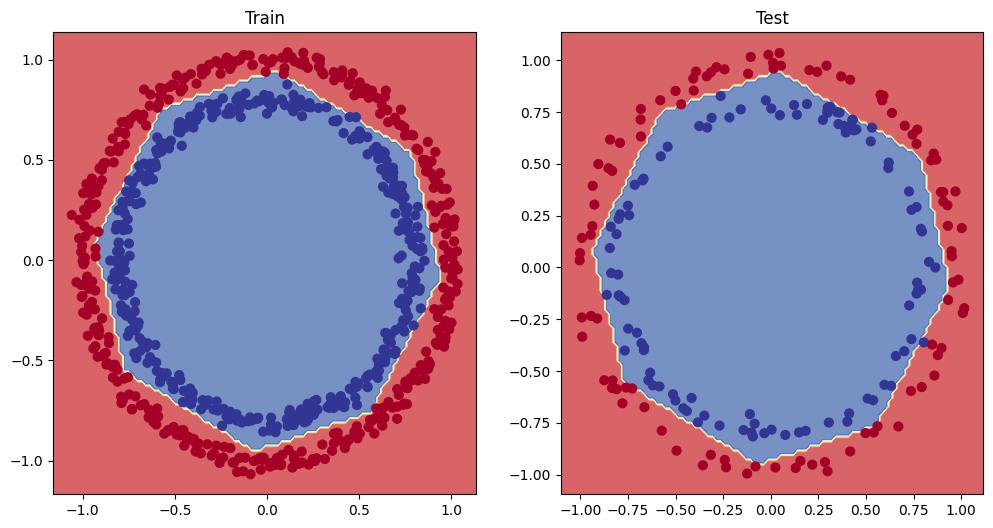

In [16]:
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(122)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test);

## 5. Improving Model

In [17]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2,  out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    # z = self.layer_1(x)
    # z = self.layer_2(z)
    # z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [18]:
# Loss function
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [19]:
torch.manual_seed(42)

epochs = 1000
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  # Forward prop
  model_1.train()
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # Loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_pred)

  # Zero grad
  optimizer.zero_grad()

  # Back propagation
  loss.backward()

  # Gradient descent
  optimizer.step()

  # Testing
  model_1.eval()
  with torch.inference_mode():
    # Forward propagation
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # Loss
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_pred)

  if epoch % 100 ==0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test loss: {test_loss:.5f} | Accuracy {acc} | Test accuracy {test_acc}")

Epoch: 0 | Loss: 0.69396 | Test loss: 0.69261 | Accuracy 50.875 | Test accuracy 51.0
Epoch: 100 | Loss: 0.69305 | Test loss: 0.69379 | Accuracy 50.375 | Test accuracy 48.0
Epoch: 200 | Loss: 0.69299 | Test loss: 0.69437 | Accuracy 51.125 | Test accuracy 46.0
Epoch: 300 | Loss: 0.69298 | Test loss: 0.69458 | Accuracy 51.625 | Test accuracy 45.0
Epoch: 400 | Loss: 0.69298 | Test loss: 0.69465 | Accuracy 51.125 | Test accuracy 46.0
Epoch: 500 | Loss: 0.69298 | Test loss: 0.69467 | Accuracy 51.0 | Test accuracy 46.0
Epoch: 600 | Loss: 0.69298 | Test loss: 0.69468 | Accuracy 51.0 | Test accuracy 46.0
Epoch: 700 | Loss: 0.69298 | Test loss: 0.69468 | Accuracy 51.0 | Test accuracy 46.0
Epoch: 800 | Loss: 0.69298 | Test loss: 0.69468 | Accuracy 51.0 | Test accuracy 46.0
Epoch: 900 | Loss: 0.69298 | Test loss: 0.69468 | Accuracy 51.0 | Test accuracy 46.0


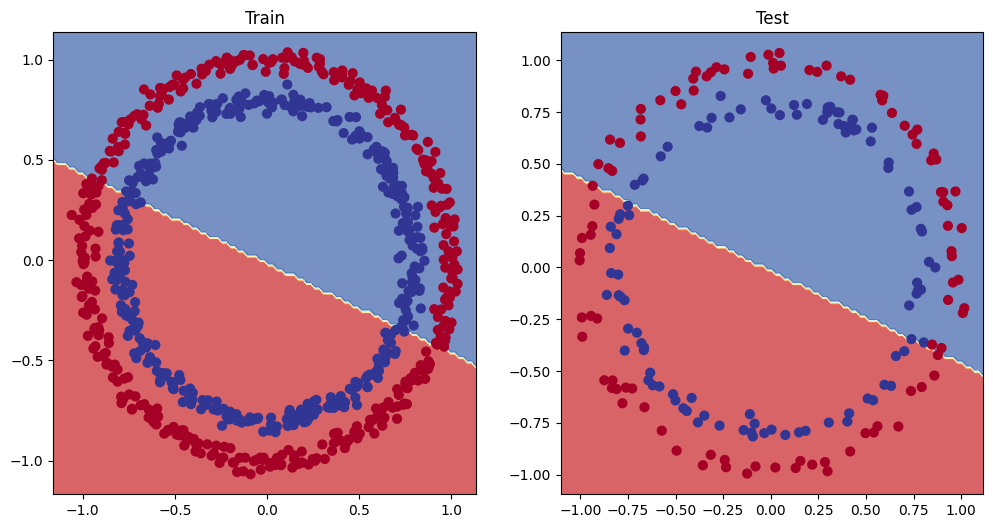

In [20]:
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(122)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test);

In [21]:
from sklearn.model_selection import train_test_split

# Try to fit with straight line
# Prepare the data
w = 0.7
b = 0.3
X_regression = torch.arange(0, 1, 0.01).unsqueeze(dim=1)
y_regression = w * X_regression + b

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_regression, y_regression, test_size=0.2)

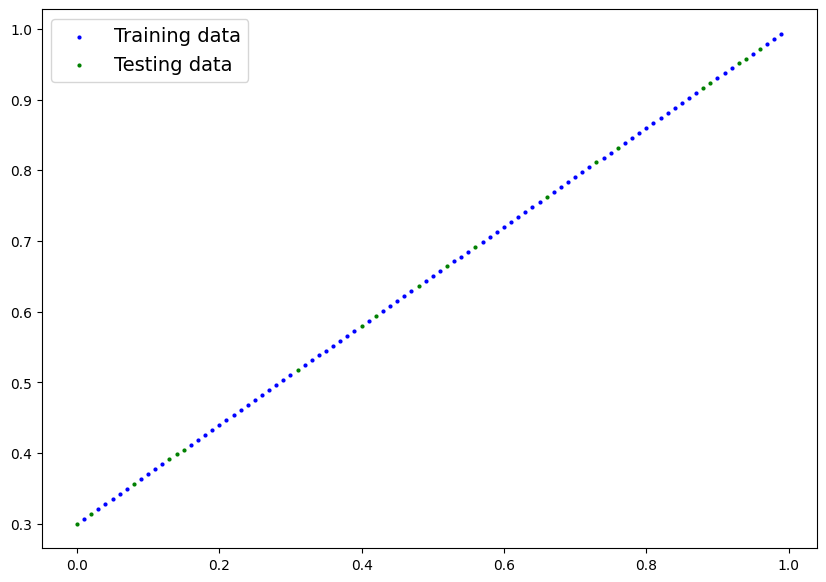

In [22]:
plot_predictions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test)

In [23]:
# Model 1
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

In [24]:
# Loss & optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)

# Train model
torch.manual_seed(42)
epoch = 10000
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  # Forward pass
  model_2.train()
  y_pred = model_2(X_train)

  # Loss
  loss = loss_fn(y_pred, y_train)

  # Zero grad
  optimizer.zero_grad()

  # Back propagation
  loss.backward()

  # GD
  optimizer.step()

  # Test
  model_2.eval()
  with torch.inference_mode():
    test_pred = model_2(X_test)
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 1000 == 0:
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss {test_loss}")

Epoch: 0 | Loss: 0.7983880043029785 | Test loss 0.7595486640930176


In [25]:
y.cpu().shape

torch.Size([1000])

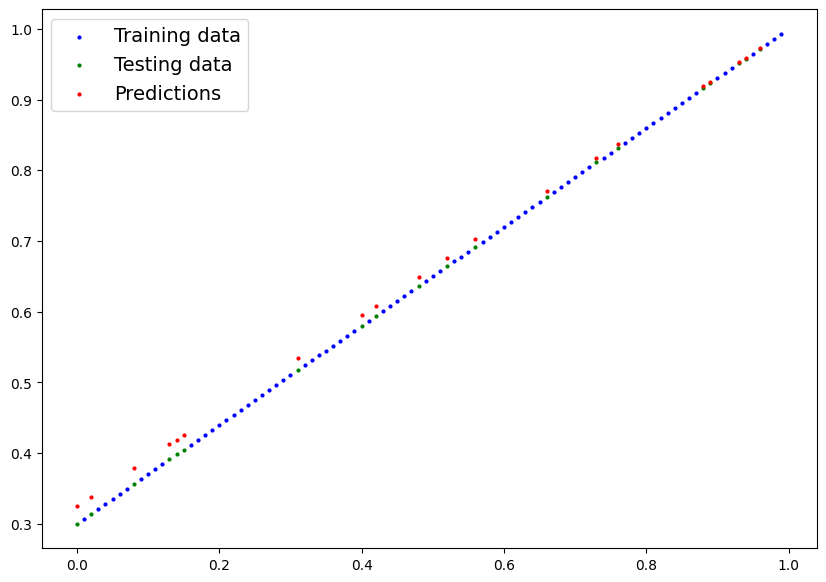

In [26]:
model_2.eval()
with torch.inference_mode():
  y_preds = model_2(X_test)

plot_predictions(train_data=X_train.cpu(),
                 train_labels=y_train.cpu(),
                 test_data=X_test.cpu(),
                 test_labels=y_test.cpu(),
                 predictions=y_preds.cpu())

## 6. Non-linearity

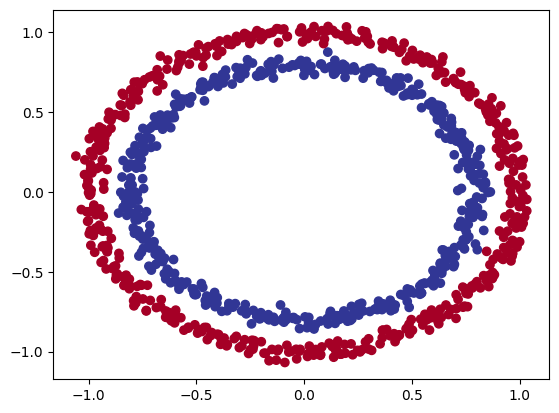

In [27]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.show()

In [28]:
import torch
from sklearn.model_selection import train_test_split

# Data preparation
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from torch import nn

# Build model
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2,  out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [30]:
# Loss & optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(), lr=0.1)

In [31]:
# Training a model
torch.manual_seed(42)

# Data
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

epochs = 1000
for epoch in range(epochs):
  # Training
  model_3.train()
  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # Loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_pred)

  # Zero grad
  optimizer.zero_grad()

  # Backpropagation
  loss.backward()

  # Step optimizer
  optimizer.step()

  # Evaluation
  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_pred)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss} | Accuracy | {acc} | Test accuracy {test_acc}")

Epoch: 0 | Loss: 0.6929463148117065 | Test loss: 0.6931881308555603 | Accuracy | 50.0 | Test accuracy 50.0
Epoch: 100 | Loss: 0.691152811050415 | Test loss: 0.6910240054130554 | Accuracy | 52.87500000000001 | Test accuracy 52.5
Epoch: 200 | Loss: 0.6897744536399841 | Test loss: 0.6893961429595947 | Accuracy | 53.37499999999999 | Test accuracy 55.00000000000001
Epoch: 300 | Loss: 0.6879494190216064 | Test loss: 0.6872316002845764 | Accuracy | 53.0 | Test accuracy 56.00000000000001
Epoch: 400 | Loss: 0.6851678490638733 | Test loss: 0.6841148734092712 | Accuracy | 52.75 | Test accuracy 56.49999999999999
Epoch: 500 | Loss: 0.6810224652290344 | Test loss: 0.6794120073318481 | Accuracy | 52.75 | Test accuracy 56.49999999999999
Epoch: 600 | Loss: 0.675148606300354 | Test loss: 0.6728507876396179 | Accuracy | 54.50000000000001 | Test accuracy 56.00000000000001
Epoch: 700 | Loss: 0.6665886640548706 | Test loss: 0.6632164120674133 | Accuracy | 58.375 | Test accuracy 59.0
Epoch: 800 | Loss: 0.651

In [32]:
# Predictions
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test)))


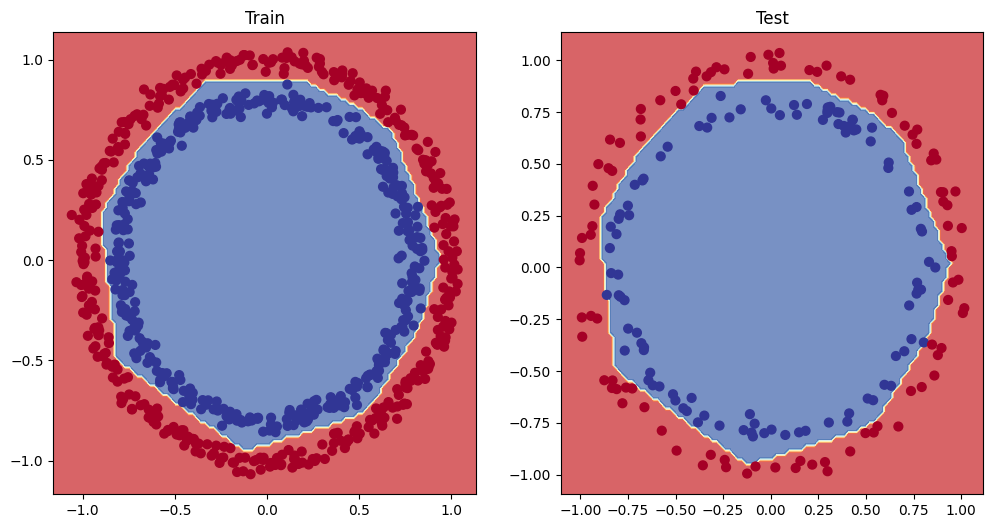

In [33]:
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(122)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test);

### 7. Replicating non-linear activation function

In [34]:
# Tensor
A = torch.arange(-10.0, 10.0, 1.0)
A.dtype

torch.float32

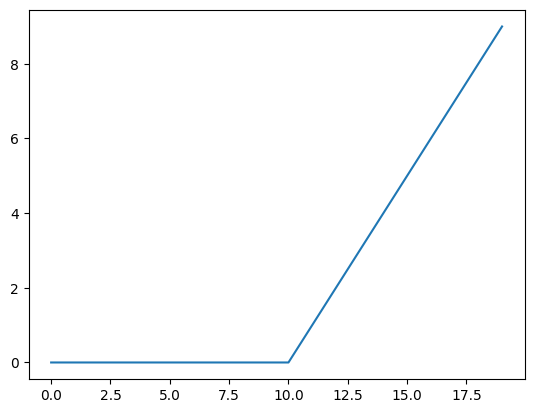

In [35]:
plt.plot(torch.relu(A));

In [36]:
def relu(x):
  return torch.maximum(torch.tensor(0), x)
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

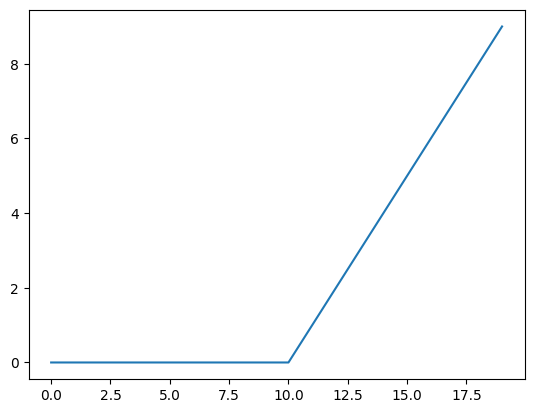

In [37]:
plt.plot(relu(A));

In [38]:
def sigmoid(x):
  return 1/(1 + torch.exp(-x))

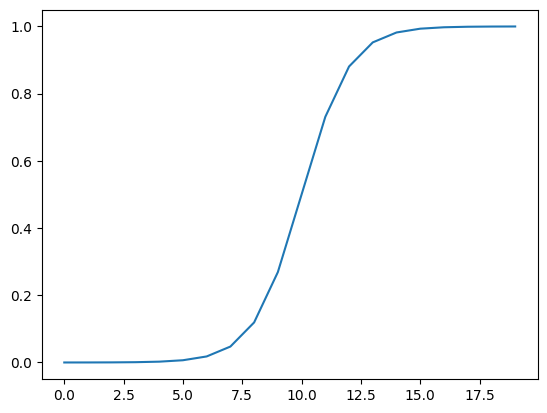

In [39]:
plt.plot(torch.sigmoid(A));

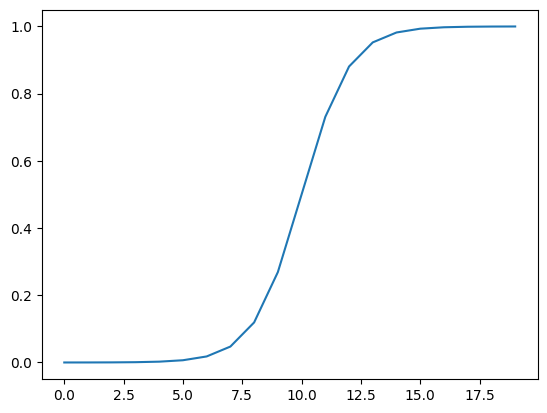

In [40]:
plt.plot(sigmoid(A));

## 8. Multiclass classification

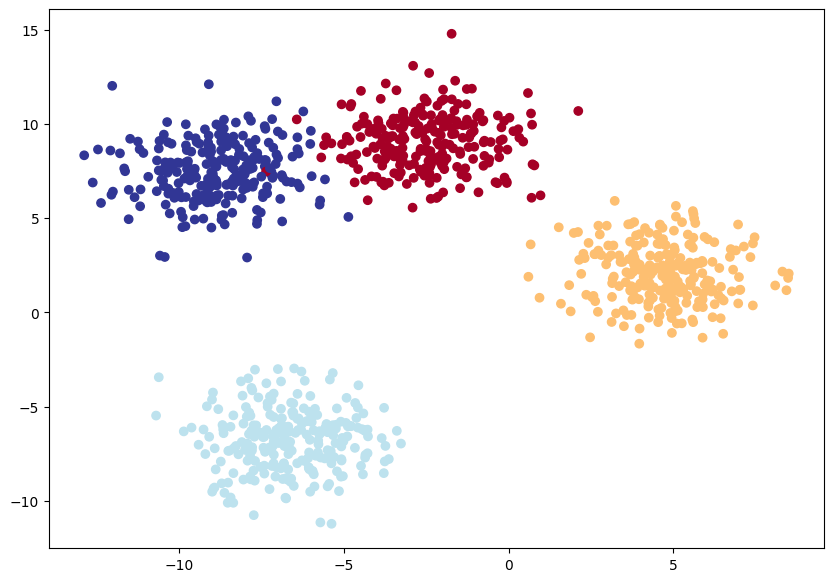

In [95]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Data preparation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(n_samples=1000, n_features=NUM_FEATURES, centers=NUM_CLASSES, cluster_std=1.5, random_state=RANDOM_SEED)

# To tensor
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_blob, y_blob, test_size=0.2, random_state=RANDOM_SEED)

# Visual
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);

In [96]:
# device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

# Multiclass classification
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,   out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,   out_features=output_features)
    )
  def forward(self, x):
    return self.linear_layer_stack(x)

# instance of BlobModel
model_4 = BlobModel(input_features=2, output_features=4, hidden_units=8).to(device)

In [70]:
# Check prediction model

model_4(X_test)
with torch.inference_mode():
  y_pred = model_4(X_test) # logits
  y_pred_probs = torch.softmax(y_pred, dim=1)

y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1], device='cuda:0')

In [66]:
y_pred_probs[0]

tensor([0.3169, 0.3244, 0.1405, 0.2182], device='cuda:0')

In [97]:
# Loss & optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters(), lr=0.01)

# Send to device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

epochs = 10000
for epoch in range(epochs):
  # Forward pass
  model_4.train()
  y_logits = model_4(X_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  # Loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_pred)

  # Zero grad
  optimizer.zero_grad()

  # Backprop
  loss.backward()

  # Gradinet descent
  optimizer.step()

  # Testing
  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(X_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_pred)

  if epoch % 1000==0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test loss {test_loss:.5f} | Accuracy {acc:.5f} | Test accuracy {test_acc:.5f}")

Epoch: 0 | Loss: 1.32603 | Test loss 1.33398 | Accuracy 33.00000 | Test accuracy 37.00000
Epoch: 1000 | Loss: 0.04124 | Test loss 0.03217 | Accuracy 99.25000 | Test accuracy 99.50000
Epoch: 2000 | Loss: 0.02913 | Test loss 0.01901 | Accuracy 99.25000 | Test accuracy 99.50000
Epoch: 3000 | Loss: 0.02647 | Test loss 0.01569 | Accuracy 99.25000 | Test accuracy 99.50000
Epoch: 4000 | Loss: 0.02531 | Test loss 0.01419 | Accuracy 99.25000 | Test accuracy 99.50000
Epoch: 5000 | Loss: 0.02462 | Test loss 0.01330 | Accuracy 99.25000 | Test accuracy 99.50000
Epoch: 6000 | Loss: 0.02412 | Test loss 0.01269 | Accuracy 99.25000 | Test accuracy 99.50000
Epoch: 7000 | Loss: 0.02372 | Test loss 0.01223 | Accuracy 99.25000 | Test accuracy 99.50000
Epoch: 8000 | Loss: 0.02338 | Test loss 0.01185 | Accuracy 99.25000 | Test accuracy 99.50000
Epoch: 9000 | Loss: 0.02308 | Test loss 0.01153 | Accuracy 99.25000 | Test accuracy 99.50000


In [98]:
# Make predictions
model_4.eval()
with torch.inference_mode():
  test_logits = model_4(X_test)
  test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)

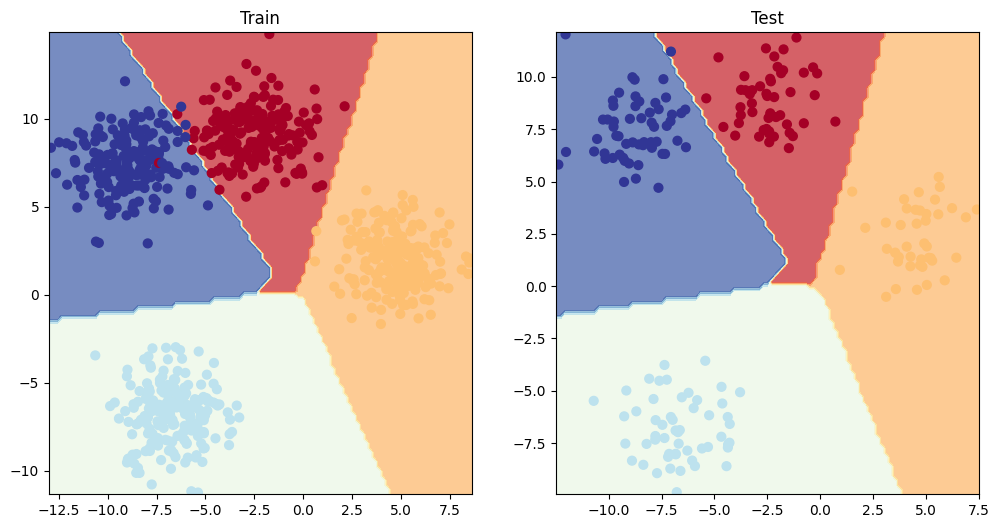

In [99]:
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.title("Train")
plot_decision_boundary(model_4, X_train, y_train)
plt.subplot(122)
plt.title("Test")
plot_decision_boundary(model_4, X_test, y_test)

## 9. Evaluation of model

* Accuracy - out of 100 samples, how many does our model get right?
* Precision
* Recall
* F1-score
8 COnfusion matrix
* Classification report


In [102]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 15.7 MB/s eta 0:00:00


In [107]:
from torchmetrics import Accuracy

acc = Accuracy(task="multiclass", num_classes=4).to(device)
acc(test_pred, y_test)

tensor(0.9950, device='cuda:0')